Event-based directional prediction on SPY with internal data and ML libraries

Outline
- Fetch data (findata)
- Construct dollar bars (mlfinlab)
- Detect events with CUSUM (mlfinlab)
- Label with triple barrier (mlfinlab)
- Build a compact feature set (pandas)
- Train a baseline classifier and evaluate with time-based splits (mlfinlab PurgedKFold)
- Produce asset_weights and asset_returns
- Call backtest(asset_weights, asset_returns)

In [10]:
#!/Users/lakshya/miniconda3/envs/finagentv2/bin/python
# Imports
import pandas as pd
import numpy as np
from pathlib import Path

# Data
from findata.equity_prices import get_equity_prices

# MLFinLab components
from mlfinlab.data_structures.standard_data_structures import get_dollar_bars
from mlfinlab.filters.filters import cusum_filter
from mlfinlab.labeling.labeling import get_events, get_bins
from mlfinlab.util.volatility import get_daily_vol
from mlfinlab.cross_validation.cross_validation import PurgedKFold, ml_cross_val_score

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 50)

1) Fetch SPY data (daily OHLCV)

In [2]:
start_date = "2015-01-01"
end_date = "2024-12-31"

spy_daily = get_equity_prices(
    tickers=["SPY"],
    start_date=start_date,
    end_date=end_date,
    fields=["Close", "High", "Low", "Volume"],
    frequency="1d",
    auto_adjust=True,
)

print(spy_daily.head())
print(spy_daily.tail())
print("Shape:", spy_daily.shape)

Price            Close        High         Low     Volume
Date                                                     
2015-01-02  170.589600  171.793694  169.551596  121465900
2015-01-05  167.508820  169.709381  167.201575  169632600
2015-01-06  165.931107  168.339270  165.133914  209151400
2015-01-07  167.998795  168.339263  166.811325  125346700
2015-01-08  170.979904  171.195817  169.393845  147217800
Price            Close        High         Low    Volume
Date                                                    
2024-12-23  587.787537  588.390442  580.839104  57635800
2024-12-24  594.320801  594.360375  588.558452  33160100
2024-12-26  594.360413  595.487135  591.138241  41219100
2024-12-27  588.103760  590.841628  583.903089  64969300
2024-12-30  581.392517  584.871680  577.626742  56578800
Shape: (2515, 4)


2) Construct dollar bars from SPY daily price/volume
Note: get_dollar_bars expects [date_time, price, volume] data. We approximate using daily close and volume.

In [3]:
# Prepare input for dollar bars: date_time, price, volume
bars_input = (
    spy_daily[["Close", "Volume"]]
    .rename(columns={"Close": "price", "Volume": "volume"})
    .assign(date_time=lambda df: df.index)
    .loc[:, ["date_time", "price", "volume"]]
)

# Construct dollar bars with a threshold tuned for daily data
bars = get_dollar_bars(
    file_path_or_df=bars_input,
    threshold=200_000_000.0,  # $200mm per bar (approx.)
    batch_size=20_000_000,
    verbose=False,
    to_csv=False,
    output_path=None,
)

# Ensure datetime index for downstream steps
bars = bars.copy()
bars["date_time"] = pd.to_datetime(bars["date_time"]) 
bars = bars.set_index("date_time").sort_index()

print(bars.head())
print(bars.tail())
print("Bars shape:", bars.shape)

                  open        high         low       close       volume  cum_buy_volume  cum_ticks  cum_dollar_value
date_time                                                                                                           
2015-01-02  170.589600  170.589600  170.589600  170.589600  121465900.0             0.0          1      2.072082e+10
2015-01-05  167.508820  167.508820  167.508820  167.508820  169632600.0             0.0          1      2.841496e+10
2015-01-06  165.931107  165.931107  165.931107  165.931107  209151400.0             0.0          1      3.470472e+10
2015-01-07  167.998795  167.998795  167.998795  167.998795  125346700.0     125346700.0          1      2.105809e+10
2015-01-08  170.979904  170.979904  170.979904  170.979904  147217800.0     147217800.0          1      2.517129e+10
                  open        high         low       close      volume  cum_buy_volume  cum_ticks  cum_dollar_value
date_time                                                        

3) Volatility target (for triple-barrier widths)

In [4]:
close_series = bars["close"].copy()

daily_vol = get_daily_vol(close_series, lookback=100)
print(daily_vol.dropna().head())
print("Non-null vol points:", daily_vol.notna().sum())

date_time
2015-01-06    0.006540
2015-01-07    0.015581
2015-01-08    0.025762
2015-01-09    0.022873
2015-01-12    0.020612
Name: close, dtype: float64
Non-null vol points: 2513


4) Event detection via CUSUM on bar returns

In [5]:
ret_series = close_series.pct_change().dropna()

# Use a fixed threshold on returns for simplicity; tune as needed
cusum_threshold = 0.01

t_events = cusum_filter(raw_time_series=ret_series, threshold=cusum_threshold, time_stamps=True)

print("#CUSUM events:", len(t_events))
print("First 5:", list(t_events[:5]))

#CUSUM events: 1127
First 5: [Timestamp('2015-01-07 00:00:00'), Timestamp('2015-01-09 00:00:00'), Timestamp('2015-01-16 00:00:00'), Timestamp('2015-01-20 00:00:00'), Timestamp('2015-01-22 00:00:00')]


5) Triple-barrier labeling (no vertical barrier), then bins

In [6]:
# Align target to bar index and forward-fill
trgt = daily_vol.reindex(close_series.index).fillna(method='ffill')

# Generate events
events = get_events(
    close=close_series,
    t_events=pd.Index(t_events),
    pt_sl=[1.0, 1.0],
    target=trgt,
    min_ret=0.0,
    num_threads=4,
    vertical_barrier_times=False,
    side_prediction=None,
    verbose=False,
)

print("Events head:\n", events.head())
print("Events shape:", events.shape)

# Convert to bins/labels
labels = get_bins(triple_barrier_events=events, close=close_series)
print("Labels head:\n", labels.head())
print("Labels value counts:\n", labels['bin'].value_counts(dropna=False))

/var/folders/jr/prby656n267_0pztcwybgy5r0000gn/T/ipykernel_87487/1389878765.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trgt = daily_vol.reindex(close_series.index).fillna(method='ffill')


Events head:
                    t1      trgt   pt   sl
2015-01-07 2015-01-08  0.015581  1.0  1.0
2015-01-09 2015-01-15  0.022873  1.0  1.0
2015-01-16 2015-01-22  0.016151  1.0  1.0
2015-01-20 2015-01-22  0.015367  1.0  1.0
2015-01-22 2015-01-27  0.015658  1.0  1.0
Events shape: (1127, 4)
Labels head:
                  ret  bin
2015-01-07  0.017745  1.0
2015-01-09 -0.025606 -1.0
2015-01-16  0.022169  1.0
2015-01-20  0.019994  1.0
2015-01-22 -0.016303 -1.0
Labels value counts:
 bin
 1.0    701
-1.0    425
Name: count, dtype: int64


6) Compact feature set
- Returns over horizons: 1, 3, 5 bars
- Rolling volatility (20)
- Rolling z-score of close (20)

In [7]:
# Base series
px = close_series.copy()
ret1 = px.pct_change(1)
ret3 = px.pct_change(3)
ret5 = px.pct_change(5)

vol20 = ret1.rolling(20).std()

# Rolling z-score of price using 20 window
roll_mean = px.rolling(20).mean()
roll_std = px.rolling(20).std()
zscore20 = (px - roll_mean) / roll_std

X = pd.concat(
    {
        "ret_1": ret1,
        "ret_3": ret3,
        "ret_5": ret5,
        "vol_20": vol20,
        "zscore_20": zscore20,
    },
    axis=1,
).dropna()

print(X.head())
print("Features shape:", X.shape)

               ret_1     ret_3     ret_5    vol_20  zscore_20
date_time                                                    
2015-02-02  0.012384  0.008894 -0.017182  0.011050  -0.234639
2015-02-03  0.014462  0.014110  0.010358  0.010766   1.065272
2015-02-04 -0.003808  0.023113  0.019586  0.010557   0.623778
2015-02-05  0.010095  0.020800  0.020447  0.010435   1.442385
2015-02-06 -0.002765  0.003466  0.030584  0.009682   1.202642
Features shape: (2495, 5)


7) Baseline classifier and time-based CV (PurgedKFold)

In [ ]:

labels_aligned = labels.reindex(X.index).dropna()
X_model = X.loc[labels_aligned.index]
y_raw = labels_aligned["bin"].astype(int)

y = (y_raw > 0).astype(int)


samples_info_sets = events["t1"].reindex(labels.index).reindex(X_model.index)

clf = LogisticRegression(max_iter=200, solver="lbfgs")
cv = PurgedKFold(n_splits=5, samples_info_sets=samples_info_sets, pct_embargo=0.01)

cv_scores = ml_cross_val_score(
    classifier=clf,
    X=X_model,
    y=y,
    cv_gen=cv,
    sample_weight_train=None,
    sample_weight_score=None,
    scoring=log_loss,
    require_proba=True,
    n_jobs_score=1,
)

print("Fold log-loss:", cv_scores)
print("Mean log-loss:", np.mean(cv_scores))

Fold log-loss: [0.67707968 0.642616   0.63786604 0.71916568 0.66806343]
Mean log-loss: 0.6689581653369105


8) Fit on all data to produce asset_weights, then compute asset_returns

In [ ]:
final_clf = LogisticRegression(max_iter=200, solver="lbfgs")
final_clf.fit(X_model, y)

# Predicted probability for class 1 (up move)
proba = pd.Series(final_clf.predict_proba(X_model)[:, 1], index=X_model.index, name="p_up")

# Convert to weights in [-1, 1]
weights_series = (2.0 * proba - 1.0).clip(-1.0, 1.0)
asset_weights = weights_series.to_frame("SPY")

# Compute asset returns from dollar-bar closes
bar_rets = close_series.pct_change().rename("SPY").to_frame()
# Align, apply 1-bar execution lag
asset_weights = asset_weights.reindex(bar_rets.index).shift(1).fillna(0.0)
asset_returns = (asset_weights["SPY"] * bar_rets["SPY"]).to_frame("SPY")

print("asset_weights head:\n", asset_weights.head())
print("asset_returns head:\n", asset_returns.head())

asset_weights head:
             SPY
date_time      
2015-01-02  0.0
2015-01-05  0.0
2015-01-06  0.0
2015-01-07  0.0
2015-01-08  0.0
asset_returns head:
             SPY
date_time      
2015-01-02  NaN
2015-01-05 -0.0
2015-01-06 -0.0
2015-01-07  0.0
2015-01-08  0.0


<Axes: xlabel='date_time'>

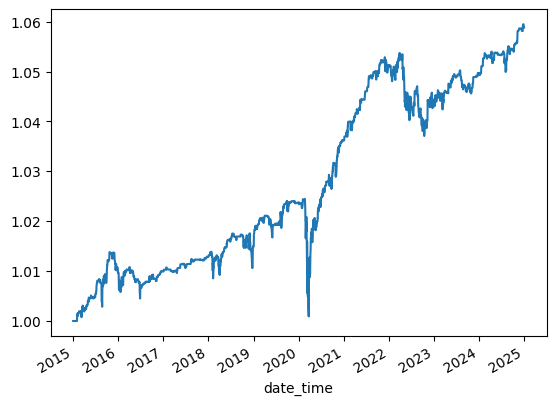

In [12]:
((asset_weights* asset_returns).sum(axis=1)+1).cumprod().plot()

9) Run user-defined backtest (expects function `backtest(asset_weights, asset_returns)`)

In [ ]:
# 9) Final: call user-defined backtest once
# Expects a function backtest(asset_weights: pd.DataFrame, asset_returns: pd.DataFrame)
backtest(asset_weights, asset_returns)